In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import numpy as np
from scipy import stats

This script is used to analyze the results of the I2R Langley Analysis. The main sections work to:
- Plot the histogram distributions of Langley slopes for each band.
- Plot box plots of the Langley slopes for each band.
- Compute the Angstrom exponent between each band.
- Extrapolate AOD to 700nm (VIIRS DNB peak spectral response).

In [ ]:
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_04_01_032300_042815/Angstrom_Overnight_2026_04_01_allBands_Langley.xlsx"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_04_22_060000_070000/Angstrom_Overnight_2026_04_22_allBands_Langley.xlsx"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_06_03_070000_080000/Angstrom_Overnight_2026_06_03_allBands_Langley.xlsx"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_06_06_080000_090000/Angstrom_Overnight_2026_06_06_allBands_Langley.xlsx"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_08_19_042000_050000/Angstrom_Overnight_2026_08_19_allBands_Langley.xlsx"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_08_19_034500_043000/Angstrom_Overnight_2026_08_19_allBands_Langley.xlsx"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_07_15_034500_043000/Angstrom_Overnight_2026_07_15_allBands_Langley.xlsx"
fname = '/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_08_23_053000_063000/Angstrom_Overnight_2026_08_23_allBands_Langley.xlsx'
# fname = '/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2026_08_27_030000_043000/Angstrom_Overnight_2026_08_27_allBands_Langley.xlsx'

df = pd.read_excel(fname, sheet_name=None)
for i in df:
    print(i)
len(df['Band 450']['Langley_slope'])-1

All Bands
Band 450
Band 470
Band 490
Band 520


20

## Histrograms

In [7]:
def make_hist_single(dataframe, band="450", color='blue'):
    kde = stats.gaussian_kde(dataframe[f'Band {band}']['Langley_slope'])

    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(
        dataframe[f'Band {band}']['Langley_slope'],
        bins=20,
        # edgecolor='grey',
        color=color,
        alpha=0.6,
        range=(-1.0, 0),
        density=True
        )
    ax.set_xlabel('Langley Slope')
    ax.set_ylabel('Star Counts')
    ax.set_title(f'Langley Slope Distribution: Band {band}nm')
    xx = np.linspace(np.amin(dataframe[f'Band {band}']['Langley_slope']), 
                     np.amax(dataframe[f'Band {band}']['Langley_slope']),
                     1000)
    ax.plot(xx, kde(xx), color='black', alpha=0.8)
    plt.tight_layout()
    plt.show()

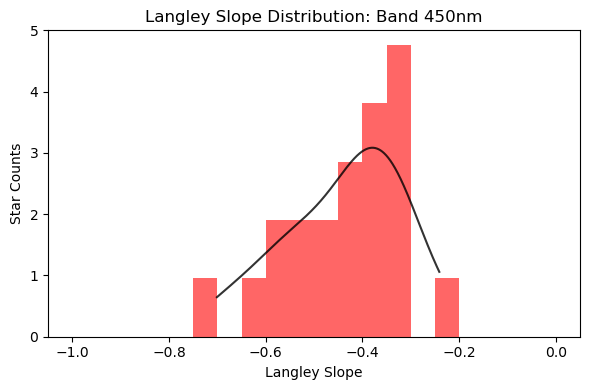

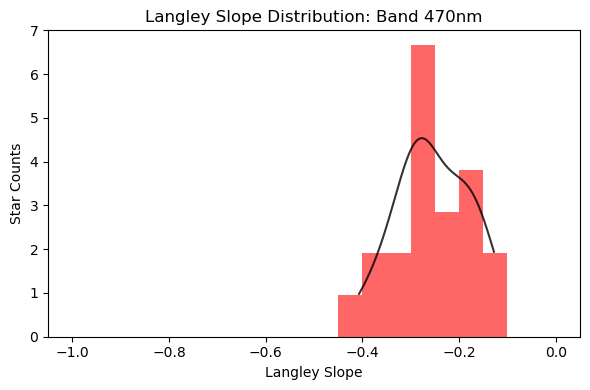

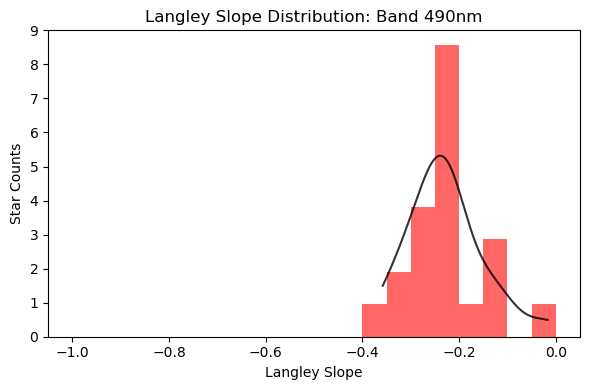

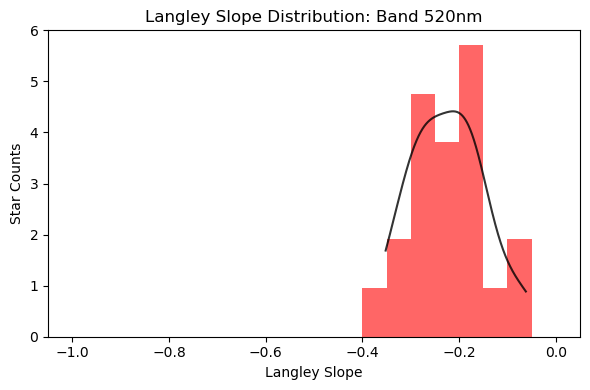

In [8]:
make_hist_single(dataframe=df, band='450', color='red')
make_hist_single(dataframe=df, band='470', color='red')
make_hist_single(dataframe=df, band='490', color='red')
make_hist_single(dataframe=df, band='520', color='red')

## Account for Atmospheric ODs

In [9]:
# Ozone absorption coefficients at each band
a450 = 4.199999999999999740e-03
a470 = 1.009999999999999960e-02
a490 = 2.129999999999999949e-02
a520 = 4.809999999999999692e-02
a = [a450, a470, a490, a520]

# Read the Ozone absorption coefficient data
with open('./o3_coeff.txt', 'r') as f:
    lams = []
    coeffs = []
    for line in f:
        lams.append(float(line.split(' ')[0]))
        coeffs.append(float(line.split(' ')[1]))
    f.close()

# Ozone column amount in atm-cm from DU
o3_du = 300 / 1000 # estimated
tau_o3 = np.array([o3_du*a_lam for a_lam in a])

In [12]:
import rayleigh_scattering as rs
from datetime import datetime, timedelta
import srf_aod as srf

# Format the date-time string
_,_,datestr = fname.partition('Angstrom_Overnight_')[0:10]
timestr = datestr[11:24].replace('_', '-')
datestr = datestr[0:10].replace('_', '/')
datestr = datestr + ' ' + timestr + 'UTC'

# Create the start and end times
stimestr = datestr.split(' ')[1].split('-')[0]
etimestr = datestr.split(' ')[1].split('-')[1][:-3]
date = datestr.split(' ')[0].replace('/', '-')
stimestr = date+' '+stimestr
etimestr = date+' '+etimestr
stime = datetime.strptime(stimestr, '%Y-%m-%d %H%M%S')
etime = datetime.strptime(etimestr, '%Y-%m-%d %H%M%S')
# THESE are used in the Open Meteo API
sday = datetime.strftime(stime, '%Y-%m-%d')
eday = datetime.strftime(stime+timedelta(days=1), '%Y-%m-%d')

stime_str = stime.strftime('%Y-%m-%d')
etime_str = stime.strftime('%Y-%m-%d')

# Pressure for Rayleigh calculation
pressure = srf.get_pressure(lat=40.58776075373724, lon=-105.14760680964913,
                            stime=stime_str, etime=etime_str)
p_time = pressure[(pressure['time'] < etime) & (pressure['time'] > stime)]
p_av = np.mean(p_time['surface_pressure'])
print(f"Pressure at {stime_str}:    {p_av}hPa")

waves = ['450', '470', '490', '520']
wavelengths = np.array([450, 470, 490, 520])*10**(-9)

# Get the rayleigh optical depth
tau_rs = []
for w in wavelengths:
    w *= 10**6  # Convert m to µm
    tau_rs.append(srf.tau_rs(w, p_av))

for i, w in zip(tau_rs, waves):
    print(f"RS OD at {w}:   {i:.4f}")

Pressure at 2026-08-27:    848.9hPa
RS OD at 450:   0.1852
RS OD at 470:   0.1549
RS OD at 490:   0.1305
RS OD at 520:   0.1023


Detract the Ozone and Rayleigh optical depths from the TOD

In [ ]:
for i, rs, o3 in zip(df, tau_rs, tau_o3):
    if i == "All Bands":
        continue
    print(f"Working on:  {i}")
    print(f"    Ozone OD:       {o3}")
    print(f"    Rayleigh OD:    {rs}")
    print(f"    TOD:            {[j for j in df[i]['Langley_slope']]}")
    print(f"    AOD:            {[j+rs+o3 for j in df[i]['Langley_slope']]}")
    
    

Working on:  Band 450
    Ozone OD:       0.0030299999999999997
    Rayleigh OD:    0.1548554570547654
    TOD:            [-0.313, -0.35, -0.312, -0.396, -0.544, -0.401, -0.447, -0.241, -0.566, -0.431, -0.374, -0.363, -0.321, -0.395, -0.528, -0.596, -0.496, -0.342, -0.701, -0.465, -0.649]
    AOD:            [np.float64(-0.1551145429452346), np.float64(-0.19211454294523458), np.float64(-0.1541145429452346), np.float64(-0.23811454294523463), np.float64(-0.3861145429452347), np.float64(-0.24311454294523463), np.float64(-0.28911454294523464), np.float64(-0.0831145429452346), np.float64(-0.4081145429452346), np.float64(-0.27311454294523463), np.float64(-0.2161145429452346), np.float64(-0.2051145429452346), np.float64(-0.16311454294523461), np.float64(-0.23711454294523462), np.float64(-0.37011454294523466), np.float64(-0.4381145429452346), np.float64(-0.33811454294523463), np.float64(-0.18411454294523463), np.float64(-0.5431145429452345), np.float64(-0.30711454294523466), np.float64(-0.491

## Box Plots

In [1]:
def make_box(data):
    fig, ax = plt.subplots(figsize=(8,6))
    bp = ax.boxplot(data, patch_artist=True,
                    showmeans=True,
                    meanline=True)
    for patch in bp['boxes']: 
        patch.set(facecolor='red',
                  alpha=0.6)
    for median in bp['medians']:
        median.set(color='black',
                   linewidth=2,
                   linestyle=':')
    for mean in bp['means']:
        mean.set(color='black',
                 linewidth=2,
                 linestyle='-')
    for flier in bp['fliers']:
        flier.set(color='#e7298a',
                  alpha=0.5)
    for whisker in bp['whiskers']:
        whisker.set(color ='black',
                linewidth = 1,
                linestyle ="--")
    ticks = [1, 2, 3, 4]
    ax.set_xticks(ticks)
    means = [line.get_ydata()[0] for line in bp['means']]
    medians = [line.get_ydata()[0] for line in bp['medians']]
    for tick, av, dat in zip(ticks, means, data):
        ax.annotate(f"av={av:.2f}", xy=(tick-.2, 0.07), size=12)
        ax.annotate(f'N={len(dat)-1}', xy=(tick-0.2, 0.04), size=12)
    ax.set_xticklabels(['450nm', '470nm', '490nm', '520nm'])
    ax.set_ylabel('TOD')
    ax.set_title('Total Optical Depth: All Bands')
    ax.set_ylim(0., 1.)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return means, medians


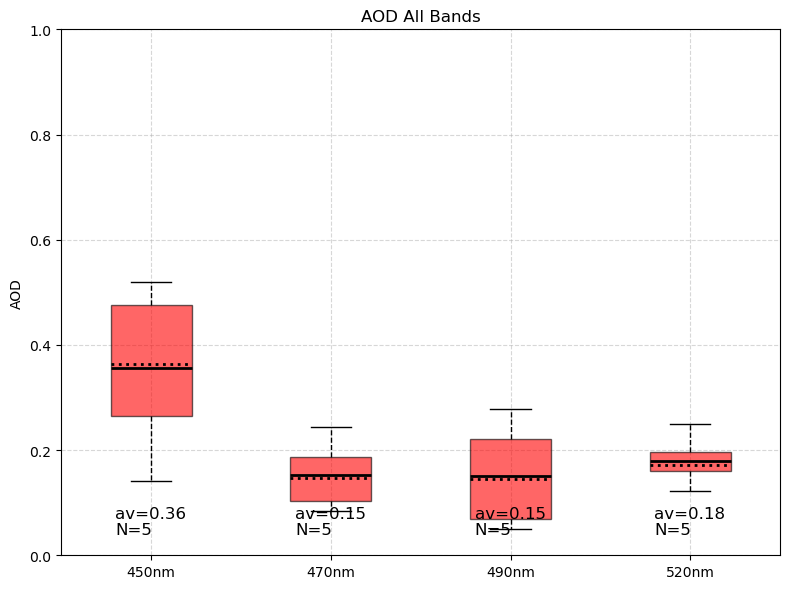

In [7]:

data = [-df['Band 450']['Langley_slope'], -df['Band 470']['Langley_slope'], -df['Band 490']['Langley_slope'], -df['Band 520']['Langley_slope']]

means, medians = make_box(data)

### Plot as Log($\tau_i$) to Log($\lambda_i$)

In [8]:


def loglog(lambdas, aods):
    """Plot the (hopefully) log-log relation of AOD and wavelength."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(lambdas, aods, marker='o', color='red')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(which='major', linestyle='-.', alpha=0.3)
    plt.tight_layout()
    plt.show()



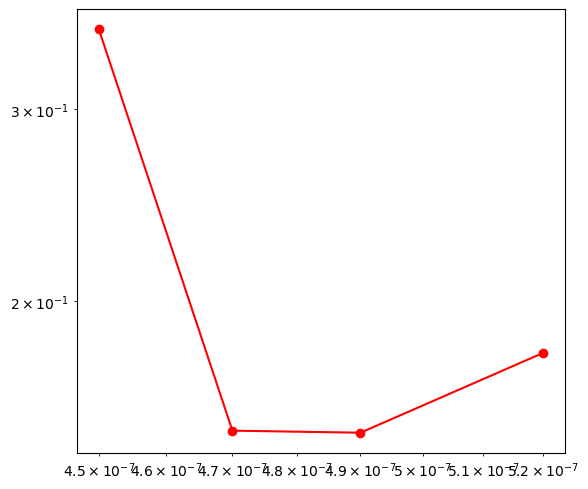

In [9]:

lambdas = np.array([450,470,490,520])*10**(-9)
aods = means
loglog(lambdas=lambdas, aods=aods)    

## Angstrom Exponents

In [10]:
# lambda1 = np.array([450, 470, 490, 520])
lambda1 = np.array([450, 490, 520])
median = [np.median(data[i]) for i in [0, 2, 3]]
# median = [np.median(data[i]) for i in [0, 1, 2, 3]]
# median = [np.median(i) for i in data]
mean = [np.mean(data[i]) for i in [0, 2, 3]]
# mean = [np.mean(data[i]) for i in [0, 1, 2, 3]]
# mean = [np.mean(i) for i in data]
mean = [np.std(data[i]) for i in [0, 2, 3]]
# mean = [np.std(data[i]) for i in [0, 1, 2, 3]]
# std = [np.std(i) for i in data]

tau = np.array(median)

angstrom = np.log(tau[:-1] / tau[1:]) / np.log(lambda1[:-1] / lambda1[1:])

for i in range(len(angstrom)):
    band_range = f"{lambda1[:-1][i]}-{lambda1[1:][i]}nm"
    print(fr"Angstrom Exponent for {band_range}: {angstrom[i]:.4f}")

Angstrom Exponent for 450-490nm: -10.7761
Angstrom Exponent for 490-520nm: 2.7755


In [11]:
angstrom_combinations = []
weights = []
from itertools import product

# Loop through each combination of bands
for i, n in product(range(len(tau)), repeat=2):
    if i != n:
        angstrom_val = np.log(tau[i] / tau[n]) / np.log(lambda1[i] / lambda1[n])
        # weight = 1 / 
        angstrom_combinations.append((i, n, angstrom_val))

# Print the outputs!
for i, n, angstrom_val in angstrom_combinations:
    band_range = f"{lambda1[i]}-{lambda1[n]}nm"
    print(fr"Angstrom Exponent for {band_range}: {angstrom_val:.4f}")

Angstrom Exponent for 450-490nm: -10.7761
Angstrom Exponent for 450-520nm: -5.2063
Angstrom Exponent for 490-450nm: -10.7761
Angstrom Exponent for 490-520nm: 2.7755
Angstrom Exponent for 520-450nm: -5.2063
Angstrom Exponent for 520-490nm: 2.7755


In [12]:
# Compute the AOD at 700nm using each Angstrom exponent:
lambda_ref = 700
aod_700nm = []

# Loop through each Combination!!! of A-exps and AODs
for i, n, angstrom_val in angstrom_combinations:
    tau_0 = tau[i]
    lambda_0 = lambda1[i]
    tau_ref = tau_0 * (lambda_ref / lambda_0)**(angstrom_val)
    aod_700nm.append(tau_ref)

# Print the results:
weights = []
for (i, n, angstrom_val), aod in zip(angstrom_combinations, aod_700nm):
    band_range = f"{lambda1[i]}-{lambda1[n]}nm"
    
    # Compute the weights
    # weights.append()
    print(fr'AOD @ 700nm via {band_range}: {aod:.4f}')
    
# NOTE: this is a Combination, not Permutation, so there are double-counts

AOD @ 700nm via 450-490nm: 0.0031
AOD @ 700nm via 450-520nm: 0.0364
AOD @ 700nm via 490-450nm: 0.0031
AOD @ 700nm via 490-520nm: 0.3902
AOD @ 700nm via 520-450nm: 0.0364
AOD @ 700nm via 520-490nm: 0.3902


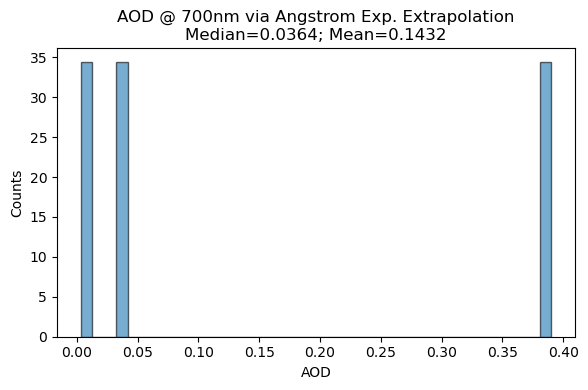

In [13]:
# Plot the 700nm AOD results as a histogram
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(
    aod_700nm,
    edgecolor='black',
    alpha=0.6,
    bins=40,
    density=True
    )
ax.set_xlabel('AOD')
ax.set_ylabel('Counts')
ax.set_title(f'AOD @ 700nm via Angstrom Exp. Extrapolation\nMedian={np.median(aod_700nm):.4f}; Mean={np.mean(aod_700nm):.4f}')
plt.tight_layout()
plt.show()